In [1]:
# Import dependencies
import pickle
from urllib.request import urlopen
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from indigopy.core import featurize
from sklearn.ensemble import RandomForestRegressor

# Load data (runtime: ~1 minute)
link = 'https://www.dropbox.com/scl/fi/75x56c2xg2za3i62py9sb/TACTIC_data.pkl?rlkey=d3yq4l0o4o6isj9ott6p2f935&st=yvradv4b&dl=1'
ecoli, mtb, master, out = pickle.load(urlopen(link))

In [2]:
# Load pretrained models
with open('./TACTIC_models.pkl', 'rb') as f: 
    data, model = pickle.load(f)

In [3]:
# Function to view keys in nested dictionary
def viewDictKeys(data, start=''):
    for key, value in data.items():
        print(f'{start}{key}')
        if isinstance(value, dict):
            viewDictKeys(value, start=start+'\t')

In [4]:
# Function to visualize dose-response checkerboards
def visualize_checkerboard(fig, axes, d_dict, label, annot:bool=True, fmt:str='.1f', cmap:str='Greens', flip:bool=False, color:str='k'): 
    
    'Visualize a checkerboard (i.e., dose-response matrix) as a heatmap.'

    # Extract metadata
    if flip: 
        strain, drug1, drug2 = label.split(', ')
        ixn = '-'.join([drug1, drug2])
        board = d_dict[label].copy().T
    else: 
        strain, drug2, drug1 = label.split(', ')
        ixn = '-'.join([drug2, drug1])
        board = d_dict[label].copy()

    # Define heatmap plot inputs
    m, n = board.shape
    board = board.reindex(index=board.index[::-1])
    control = np.array(board.iloc[-1, 0]).reshape((1, 1))
    d1_vector = board.iloc[-1, 1:].values.reshape((1, n-1))
    d2_vector = board.iloc[:-1, 0].values.reshape((m-1, 1))
    dr_matrix = board.iloc[:-1, 1:].values
    xlab = board.columns[1:].values.astype(str).reshape(n-1)
    ylab = board.index[:-1].values.astype(str).reshape(m-1)
    vmin, vmax = 0, board.max(axis=None)

    # Unpack axes
    ax0, ax1, ax2, ax3, ax4, ax5 = axes

    # Plot positive control
    ax = fig.add_subplot(ax0)
    sns.heatmap(control, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.set_xticklabels(labels=['0.0'])
    ax.set_yticklabels(labels=['0.0'], rotation=0)

    # Plot drug 1 inhibition (x-axis)
    ax = fig.add_subplot(ax1)
    sns.heatmap(d1_vector, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.tick_params(left=False, bottom=False)
    ax.set(yticklabels=[])
    ax.set_xticklabels(labels=xlab, rotation=30)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    ax.set_xlabel('[{}] (ug/mL)'.format(drug1))

    # Plot drug 2 inhibition (y-axis)
    ax = fig.add_subplot(ax2)
    sns.heatmap(d2_vector, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.tick_params(left=False, bottom=False)
    ax.set(xticklabels=[])
    ax.set_yticklabels(labels=ylab, rotation=0)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    ax.set_ylabel('[{}] (ug/mL)'.format(drug2))

    # Plot dose-response matrix
    axm = fig.add_subplot(ax3)
    axl = fig.add_subplot(ax4)
    sns.heatmap(dr_matrix, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar_ax=axl, ax=axm)
    axm.tick_params(left=False, bottom=False)
    axm.set(xticklabels=[], yticklabels=[])
    for _, spine in axm.spines.items():
        spine.set_visible(True)
    axm.set_title('{}, {}'.format(strain, ixn), fontsize=12, color=color)
    axl.set_title('Viability', fontsize=10)

    # Assign whitespace to unused axis
    ax = fig.add_subplot(ax5)
    ax.axis('off')

In [5]:
viewDictKeys(model)

Cacace
Brochado
full


## Manual vs. SynergyFinder scores

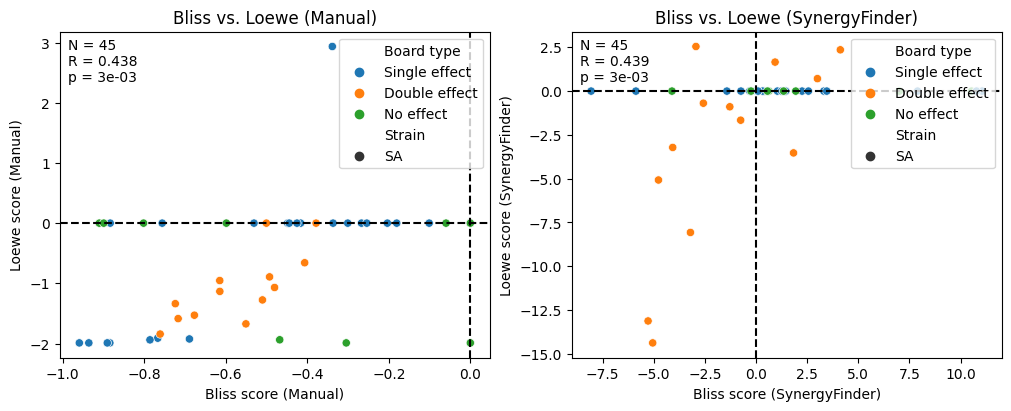

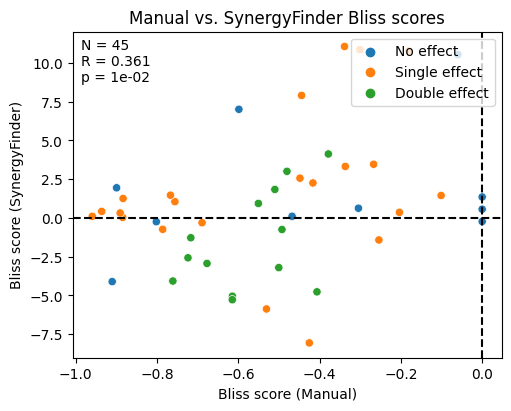

In [5]:
# Import methods
from scipy.stats import spearmanr

# Define data
df = out['validation']['all_scores'].copy()
dfp = df[df['Strain'].str.startswith('SA')]
dfp = df[df['Strain']=='SA']

# Instantiate figure
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), constrained_layout=True)

# Manual
ax, method = axs[0], 'Manual'
x, y = f'Bliss score ({method})', f'Loewe score ({method})'
r, p = spearmanr(dfp[x], dfp[y])
sns.scatterplot(data=dfp, x=x, y=y, hue='Board type', style='Strain', ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title(f'Bliss vs. Loewe ({method})')
ax.text(0.02, 0.98, f'N = {dfp.shape[0]}\nR = {r:.3f}\np = {p:.0e}', 
        ha='left', va='top', transform=ax.transAxes)
ax.legend(loc='upper right')

# SynergyFinder
ax, method = axs[1], 'SynergyFinder'
x, y = f'Bliss score ({method})', f'Loewe score ({method})'
r, p = spearmanr(dfp[x], dfp[y])
sns.scatterplot(data=dfp, x=x, y=y, hue='Board type', style='Strain', ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title(f'Bliss vs. Loewe ({method})')
ax.text(0.02, 0.98, f'N = {dfp.shape[0]}\nR = {r:.3f}\np = {p:.0e}', 
        ha='left', va='top', transform=ax.transAxes)
ax.legend(loc='upper right')

# Bliss scores (manual vs. synergy finder)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4), constrained_layout=True)
x, y = 'Bliss score (Manual)', 'Bliss score (SynergyFinder)'
r, p = spearmanr(dfp[x], dfp[y])
sns.scatterplot(data=dfp, x=x, y=y, hue='Board type', hue_order=['No effect', 'Single effect', 'Double effect'], ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title('Manual vs. SynergyFinder Bliss scores')
ax.text(0.02, 0.98, f'N = {dfp.shape[0]}\nR = {r:.3f}\np = {p:.0e}', 
        ha='left', va='top', transform=ax.transAxes)
ax.legend(loc='upper right')

In [7]:
dfp.index = [', '.join(i.split('-')) for i in dfp['Interaction']]
dfp

,Label,Strain,Interaction,Board type,Bliss score (Manual),Loewe score (Manual),Bliss score (SynergyFinder),Loewe score (SynergyFinder),Source
"A22, DXR","SA, A22, DXR",SA,A22-DXR,Single effect,-0.203595,0.000000,0.355,0.000,Karthik
"AMK, PUR","SA, AMK, PUR",SA,AMK-PUR,Double effect,-0.406499,-0.658201,-4.770,-5.078,Karthik
"AMP, CFZ","SA, AMP, CFZ",SA,AMP-CFZ,Single effect,-0.936143,-1.990008,0.417,0.000,Karthik
"AMX, CEF","SA, AMX, CEF",SA,AMX-CEF,Single effect,-0.884577,-1.990008,0.030,0.000,Karthik
"AMX, CER","SA, AMX, CER",SA,AMX-CER,Single effect,-0.756078,0.000000,1.047,0.000,Karthik
"AMX, CFX","SA, AMX, CFX",SA,AMX-CFX,Single effect,-0.767025,-1.911204,1.462,0.000,Karthik
"AMX, EGCG","SA, AMX, EGCG",SA,AMX-EGCG,Single effect,-0.883639,0.000000,1.250,0.000,Karthik
"AMX, ERY","SA, AMX, ERY",SA,AMX-ERY,No effect,0.000000,-1.990008,-0.233,0.000,Karthik
"AMX, GEN","SA, AMX, GEN",SA,AMX-GEN,Single effect,-0.890816,-1.990008,0.316,0.000,Karthik
"AMX, PQ","SA, AMX, PQ",SA,AMX-PQ,No effect,-0.910397,0.000000,-4.110,0.000,Karthik


## Checkerboard visualizations

Generating pages:   0%|          | 0/3 [00:00<?, ?it/s]

Visualizing checkerboards:   0%|          | 0/18 [00:00<?, ?it/s]

Visualizing checkerboards:   0%|          | 0/18 [00:00<?, ?it/s]

Visualizing checkerboards:   0%|          | 0/18 [00:00<?, ?it/s]

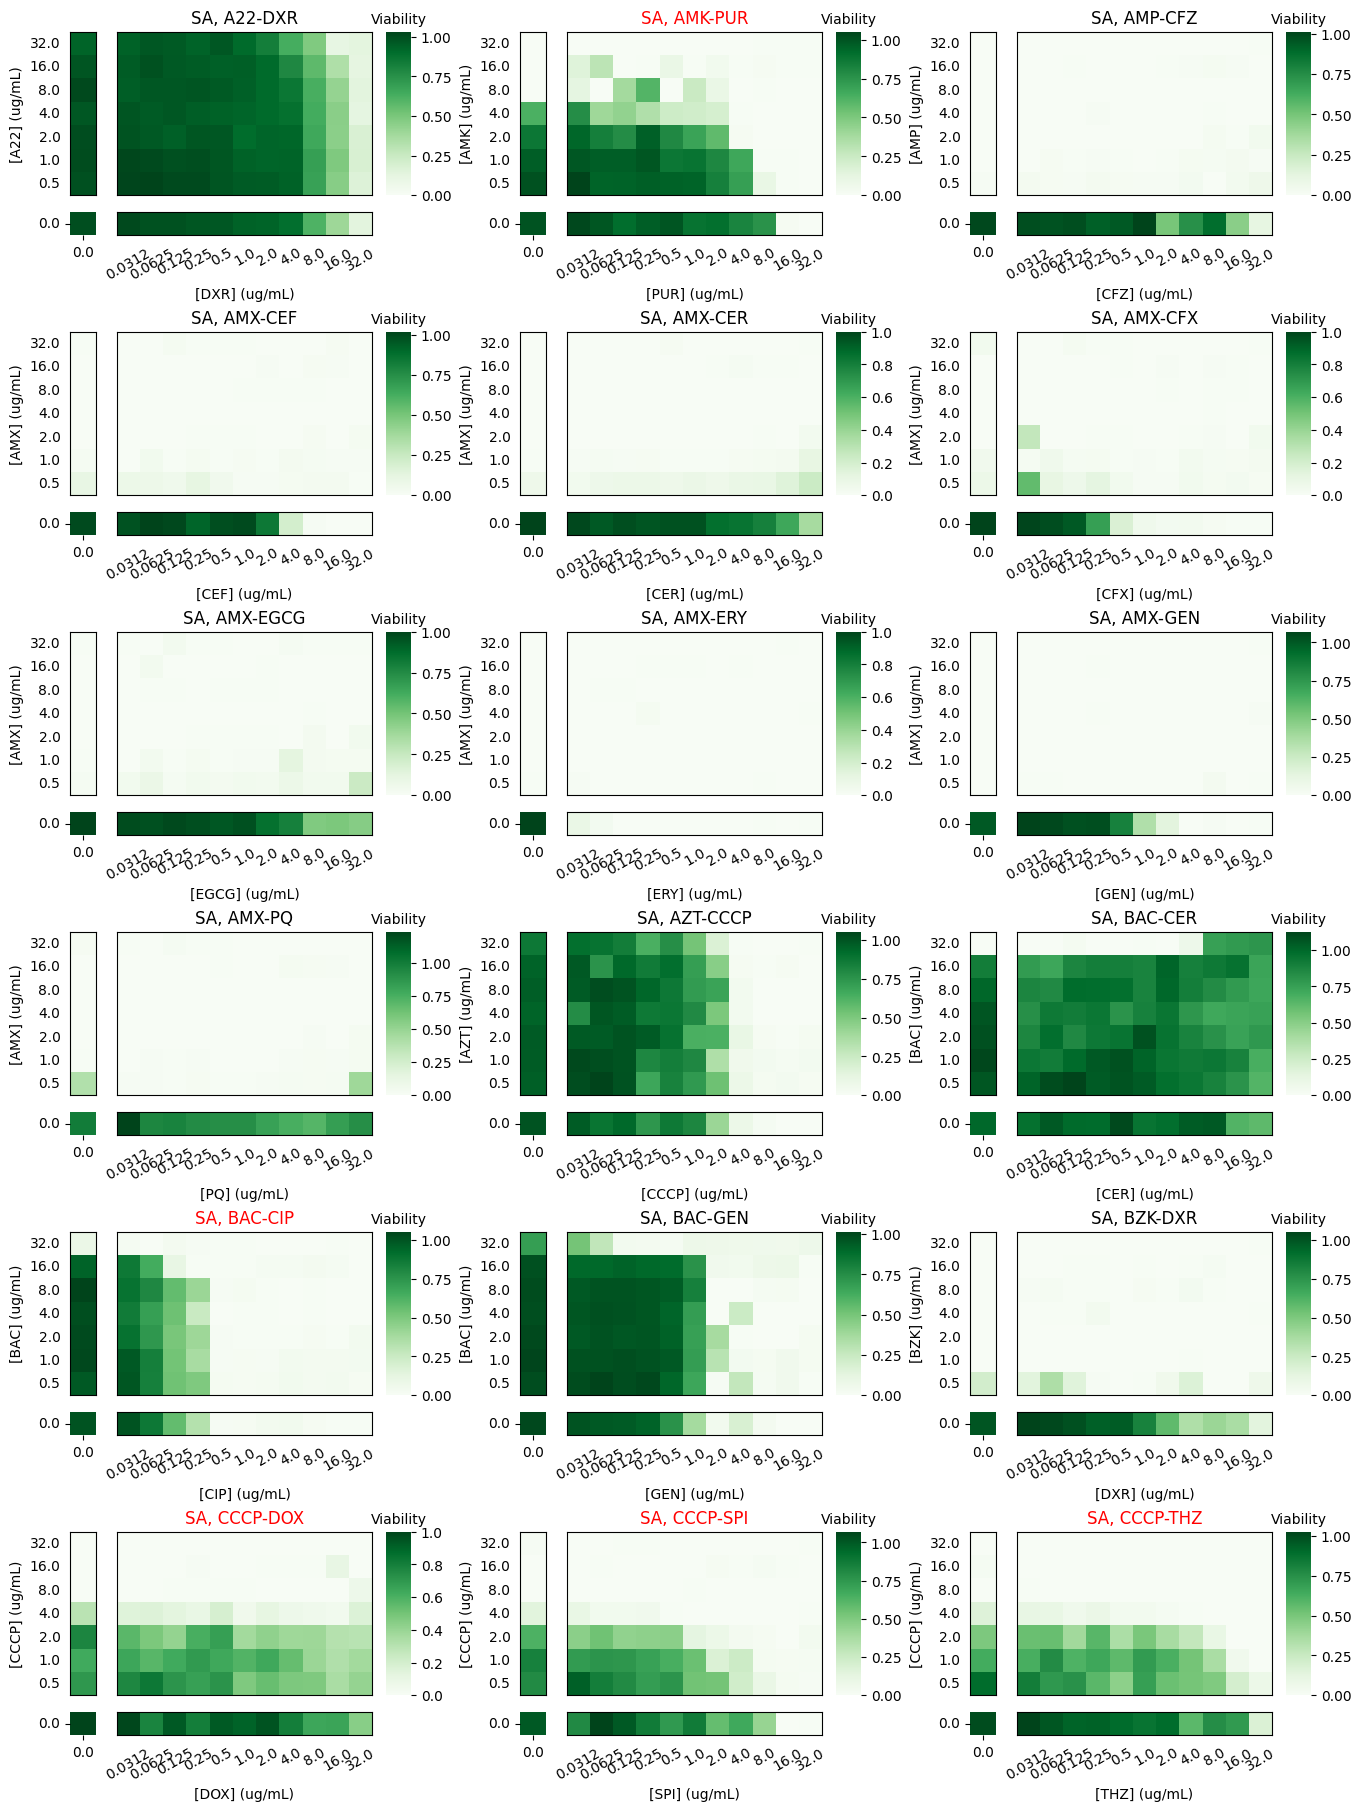

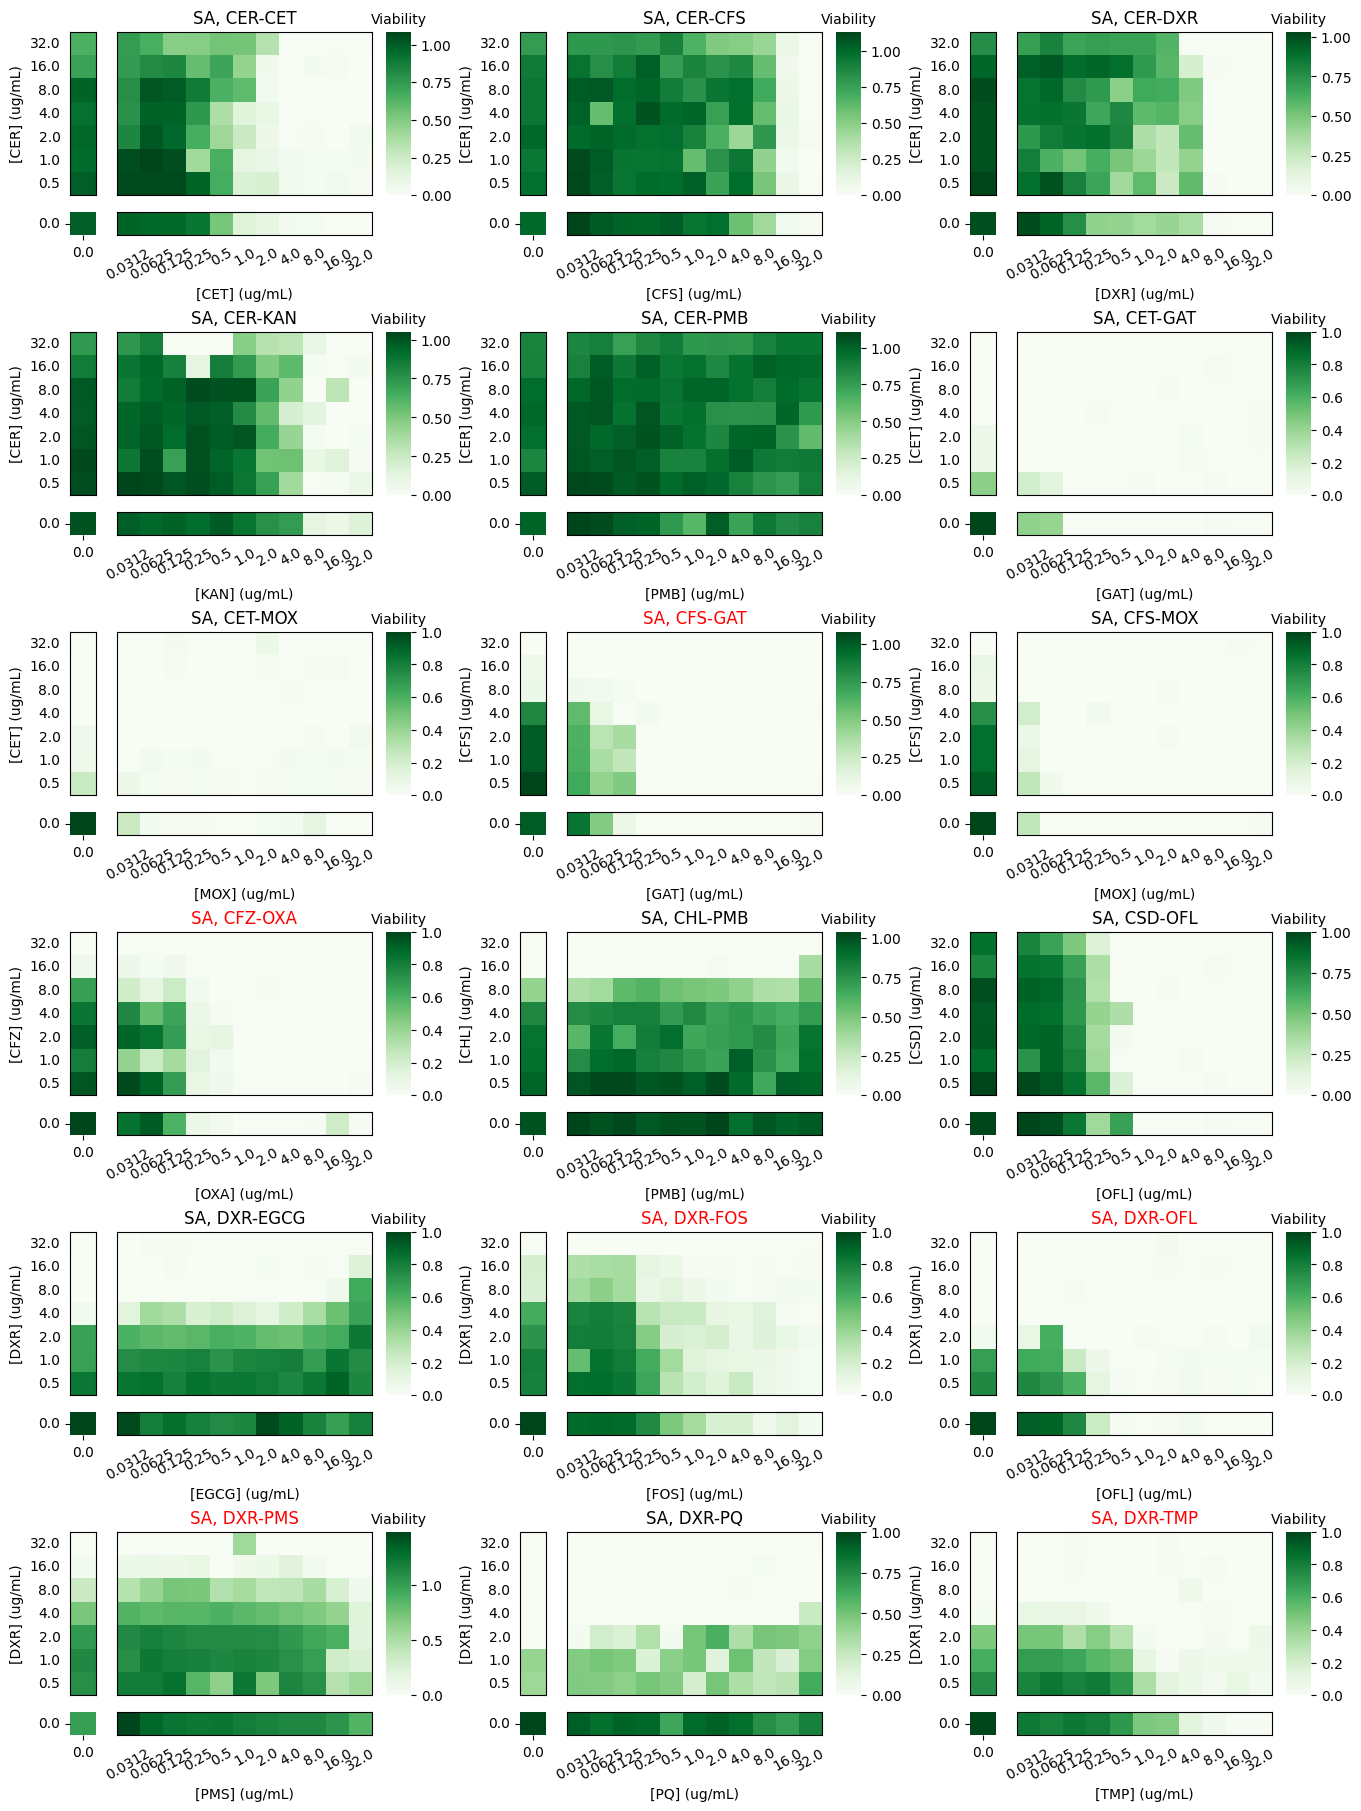

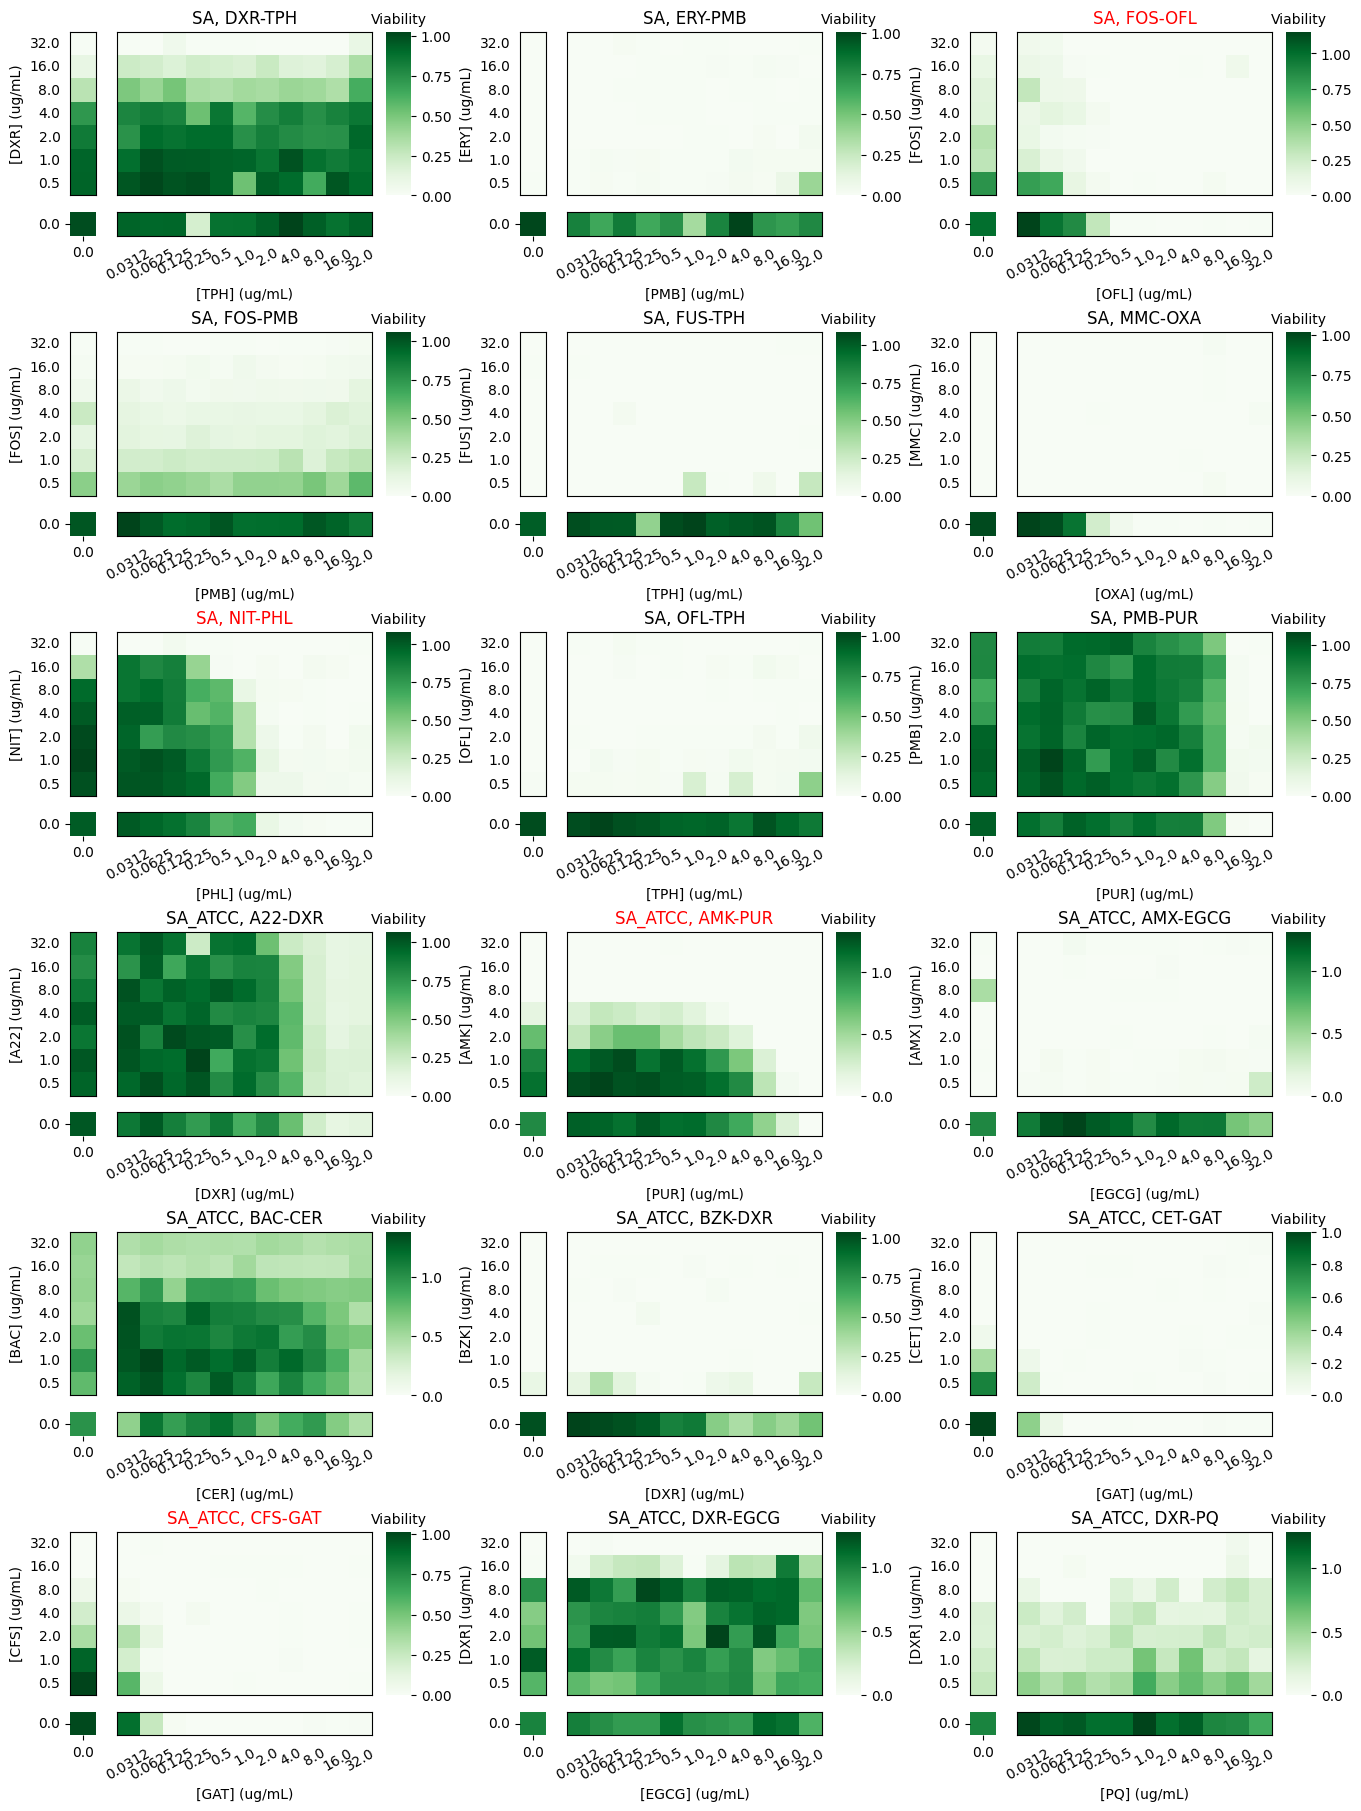

In [7]:
# Import tqdm
from tqdm.notebook import tqdm

# Define data
d_dict = out['validation']['all_boards']
# prefix = ('ATCC', 'Smooth', 'Rough', 'PS', 'SA')
prefix = 'SA'
labels = [label for label in d_dict.keys() if label.startswith(prefix)]
df = out['validation']['all_scores'].copy()
highlight = df[df['Board type']=='Double effect']['Label'].tolist()

# Define figure dimensions
width, height = [0.1, 1, 0.1], [0.7, 0.1]
m, n, rm, rn = 6, 3, len(height), len(width)
rows = len(labels) // n
if len(labels) % n > 0:
    rows += 1
pages = rows // m
if rows % m > 0:
    pages += 1

# Plot checkerboards
files = {}
for page in tqdm(range(0, pages), desc='Generating pages'):
    # Adjust row length based on page
    if page == pages - 1:
        k, start, end = 0, page*(m*n), len(labels)
        items = len(labels) - page*m*n
        m = items // n
        if items % n > 0:
            m += 1
    else:
        k, start, end = 0, page*(m*n), (page+1)*m*n
    # Instantiate figure
    fig = plt.figure(figsize=(4.5*n, 3*m), layout='constrained')
    gs = fig.add_gridspec(m*rm, n*rn, width_ratios=n*width, height_ratios=m*height)
    # Generate plots
    for label in tqdm(labels[start:end], desc='Visualizing checkerboards', leave=False): 
        # Define axis coordinates
        if ('Smooth, AMP-CLA' in labels) and (page == 0) and (k < 5): 
            if 'MEC' in label: 
                if label.startswith('ATCC'): 
                    p = 3
                else: 
                    p = 4
            else: 
                p = k // 2
            i, j = rm*(p // n), rn*(p % n)
        else: 
            i, j = rm*(k // n), rn*(k % n)
        # Define axis
        axes = (gs[i+1, j], gs[i+1, j+1], gs[i, j], gs[i, j+1], gs[i, j+2], gs[i+1, j+2])
        # Account for source
        flip = label.startswith(('ATCC', 'Smooth', 'Rough', 'PS4'))
        if label in highlight:
            color = 'r'
        else:
            color = 'k'
        # Generate plot
        visualize_checkerboard(fig, axes, d_dict, label, annot=False, fmt='.1f', cmap='Greens', flip=flip, color=color)
        # Update counter
        k += 1
    # Save figure
    files[page] = fig

## S. aureus predictions

In [6]:
# Instantiate output variable
out['Saureus'] = dict()
endo = out['endophthalmitis'].copy()
dkey = pd.read_excel('./data/Endophthalmitis/endophthalmitis_data.xlsx', sheet_name='key', engine='openpyxl')

# Define keys
ekey = list(zip(dkey['Code'], dkey['ecoli_label']))
ekey = [key for key in ekey if not pd.isna(key[1])]
mkey = list(zip(dkey['Code'], dkey['mtb_label']))

# Define interactions of interest
ixn_list = [list(i.split(', ')) for i in list(endo.index)]

# Define strain of interest (S. aureus)
str_list = [s for s in out['strains'] if 'aureus' in s] * len(ixn_list)

In [7]:
# Import featurize method
from scipy import sparse
from indigopy.core import featurize

# Define phenotype data + feature names + orthology maps
p1, p2  = ecoli['omics'].iloc[:, 1:].to_dict('list'), mtb['omics'].iloc[:, 1:].to_dict('list')
g1, g2  = ecoli['omics']['Gene'].tolist(), mtb['omics']['Gene'].tolist()

# Determine features
f1      = featurize(ixn_list, p1, feature_names=g1, key=ekey, strains=str_list, orthology_map=ecoli['map'])
f2      = featurize(ixn_list, p2, feature_names=g2, key=mkey, strains=str_list, orthology_map=mtb['map'])
d1, d2  = f1['feature_df'].to_numpy().transpose(), f2['feature_df'].to_numpy().transpose()

# Re-format input data
x1      = np.zeros([d2.shape[0], d1.shape[1]], dtype=d2.dtype)
x1[np.array(f1['idx'])] = d1[np.array(f1['idx'])]
idx1    = [f in master['df'].index for f in list(f1['feature_df'].index)]
idx2    = [f in master['df'].index for f in list(f2['feature_df'].index)]
s1, s2  = sparse.csr_matrix(x1[:, np.array(idx1)]), sparse.csr_matrix(d2[:, np.array(idx2)])
X_pred  = sparse.hstack((s1, s2))

c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:337: UserWarning: Interaction entries do not match profile names, but key provided
  warn('Interaction entries do not match profile names, but key provided')
c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:351: UserWarning: Not all feature names are unique. Enforcing unique entries for output
  warn('Not all feature names are unique. Enforcing unique entries for output')
c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:406: UserWarning: Drug profile information missing for 548 interactions
  warn('Drug profile information missing for {} interactions'.format(len(interactions) - len(ixn_list)))
Mapping orthologous genes: 100%|██████████| 1/1 [00:02<00:00,  2.21s/it]


In [8]:
pred = out['model']['TACTIC'].predict(X_pred)

## [DEPRECATED] S. aureus predictions

In [10]:
# Define model wo S. aureus input
from sklearn.ensemble import RandomForestRegressor
idx = master['data']['Strain'] != str_list[0]
X_train = master['X'][idx]
y_train = master['data']['Score'][idx].values
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [11]:
# Determine INDIGO features (runtime: ~5 minutes)
features = dict()
for key, value in tqdm(data['omics']['clean'].items(), desc='Determining INDIGO features'):
    if key.startswith('spn'):
        df = data['orthology']['map']['spn']
    else:
        df = data['orthology']['map'][key]
    map = {col: df.index[df[col]].to_list() for col in df.columns}
    features[key] = featurize(ixn_list, value.to_dict(orient='list'), feature_names=list(value.index), 
                              strains=str_list, orthology_map=map)

# Concatenate features
skip_new = True
for key, value in features.items():
    if skip_new and (key not in ('eco', 'mtu')):
        continue
    value['feature_df'].index = [i + '_' + key if 'entropy' in i else i for i in value['feature_df'].index]
    if key.startswith('spn'):
        value['feature_df'].index = [i + '_' + key[-1] for i in value['feature_df'].index]
    if key == 'eco':
        df = value['feature_df'].copy()
    else:
        df = pd.concat([df, value['feature_df']])
features['master'] = df.copy()

# Define ML features
X_pred = sparse.csr_matrix(features['master'].to_numpy().transpose())

Determining INDIGO features:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:406: UserWarning: Drug profile information missing for 858 interactions
  warn('Drug profile information missing for {} interactions'.format(len(interactions) - len(ixn_list)))
Mapping orthologous genes: 100%|██████████| 1/1 [00:03<00:00,  3.37s/it]
c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:406: UserWarning: Drug profile information missing for 350 interactions
  warn('Drug profile information missing for {} interactions'.format(len(interactions) - len(ixn_list)))
Mapping orthologous genes: 100%|██████████| 1/1 [00:02<00:00,  2.99s/it]
c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:351: UserWarning: Not all feature names are unique. Enforcing unique entries for output
  warn('Not all feature names are unique. Enforcing unique entries for output')
c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\sit

In [12]:
X_pred.shape

(2628, 31668)

In [9]:
# Import featurize method
from scipy import sparse
from indigopy.core import featurize

# Define phenotype data + feature names + orthology maps
p1, p2  = ecoli['omics'].iloc[:, 1:].to_dict('list'), mtb['omics'].iloc[:, 1:].to_dict('list')
g1, g2  = ecoli['omics']['Gene'].tolist(), mtb['omics']['Gene'].tolist()

# Determine features
f1      = featurize(ixn_list, p1, feature_names=g1, key=ekey, strains=str_list, orthology_map=ecoli['map'])
f2      = featurize(ixn_list, p2, feature_names=g2, key=mkey, strains=str_list, orthology_map=mtb['map'])
d1, d2  = f1['feature_df'].to_numpy().transpose(), f2['feature_df'].to_numpy().transpose()

# Re-format input data
x1      = np.zeros([d2.shape[0], d1.shape[1]], dtype=d2.dtype)
x1[np.array(f1['idx'])] = d1[np.array(f1['idx'])]
idx1    = [f in master['df'].index for f in list(f1['feature_df'].index)]
idx2    = [f in master['df'].index for f in list(f2['feature_df'].index)]
s1, s2  = sparse.csr_matrix(x1[:, np.array(idx1)]), sparse.csr_matrix(d2[:, np.array(idx2)])
X_pred  = sparse.hstack((s1, s2))


c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:337: UserWarning: Interaction entries do not match profile names, but key provided
  warn('Interaction entries do not match profile names, but key provided')
c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:351: UserWarning: Not all feature names are unique. Enforcing unique entries for output
  warn('Not all feature names are unique. Enforcing unique entries for output')
c:\Users\carol\AppData\Local\Programs\Python\Python310\lib\site-packages\indigopy\core.py:406: UserWarning: Drug profile information missing for 548 interactions
  warn('Drug profile information missing for {} interactions'.format(len(interactions) - len(ixn_list)))
Mapping orthologous genes: 100%|██████████| 1/1 [00:02<00:00,  2.60s/it]


In [13]:
# Generate predictions for each model
predictions = pd.DataFrame()
for key, m in model.items():
    predictions[key] = m.predict(X_pred)
predictions.index = ['-'.join(i.split(', ')) for i in endo.index]

In [11]:
# Generate predictions (- S. aureus model)
dfp['TACTIC (- S. aureus)'] = model.predict(X_pred)

# Generate predictions (full TACTIC model)
dfp['TACTIC (+ S. aureus)'] = out['model']['TACTIC'].predict(X_pred)

In [22]:
df = out['validation']['all_scores'].copy()
dfp = df[df['Strain'].str.startswith('SA')]
dfp.index = dfp['Interaction']
dfp.head()

,Label,Strain,Interaction,Board type,Bliss score (Manual),Loewe score (Manual),Bliss score (SynergyFinder),Loewe score (SynergyFinder),Source
Interaction,,,,,,,,,
A22-DXR,"SA, A22, DXR",SA,A22-DXR,Single effect,-0.203595,0.000000,0.355,0.000,Karthik
AMK-PUR,"SA, AMK, PUR",SA,AMK-PUR,Double effect,-0.406499,-0.658201,-4.770,-5.078,Karthik
AMP-CFZ,"SA, AMP, CFZ",SA,AMP-CFZ,Single effect,-0.936143,-1.990008,0.417,0.000,Karthik
AMX-CEF,"SA, AMX, CEF",SA,AMX-CEF,Single effect,-0.884577,-1.990008,0.030,0.000,Karthik
AMX-CER,"SA, AMX, CER",SA,AMX-CER,Single effect,-0.756078,0.000000,1.047,0.000,Karthik


In [24]:
dfp = pd.concat([dfp, predictions.loc[dfp.index]], axis=1)

In [25]:
dfp.head()

,Label,Strain,Interaction,Board type,Bliss score (Manual),Loewe score (Manual),Bliss score (SynergyFinder),Loewe score (SynergyFinder),Source,Cacace,Brochado,full
Interaction,,,,,,,,,,,,
A22-DXR,"SA, A22, DXR",SA,A22-DXR,Single effect,-0.203595,0.000000,0.355,0.000,Karthik,0.005022,0.016943,0.043748
AMK-PUR,"SA, AMK, PUR",SA,AMK-PUR,Double effect,-0.406499,-0.658201,-4.770,-5.078,Karthik,-0.011523,-0.000742,-0.053398
AMP-CFZ,"SA, AMP, CFZ",SA,AMP-CFZ,Single effect,-0.936143,-1.990008,0.417,0.000,Karthik,-0.020826,-0.022267,0.019741
AMX-CEF,"SA, AMX, CEF",SA,AMX-CEF,Single effect,-0.884577,-1.990008,0.030,0.000,Karthik,0.025556,0.019348,0.500900
AMX-CER,"SA, AMX, CER",SA,AMX-CER,Single effect,-0.756078,0.000000,1.047,0.000,Karthik,0.034587,0.029731,0.013435


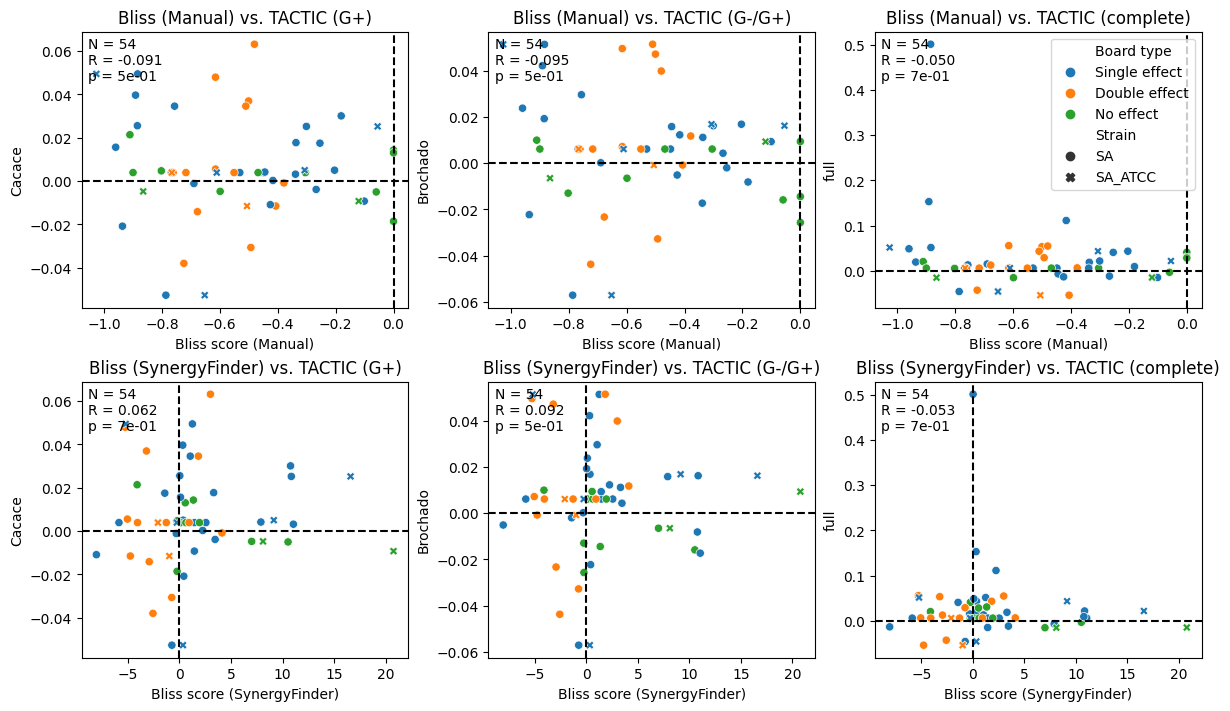

In [31]:
# Instantiate figure
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 7), constrained_layout=True)
hue = 'Board type'
style = 'Strain'

# First half (- S. aureus model)
sa_list = ['-', '-', '+', '+']
method_list = ['Manual', 'SynergyFinder'] * 2
rows = ['Manual'] * 3 + ['SynergyFinder'] * 3
cols = list(model.keys()) * 2
model_dict = {'Cacace': 'G+', 'Brochado': 'G-/G+', 'full': 'complete'}

# Generate figure
k = 0
for row, col in zip(rows, cols):
    # Define axis
    i, j = k // 3, k % 3
    ax = axs[i, j]
    # Define plot inputs
    # x, y = f'Bliss score ({method})', f'TACTIC ({sa} S. aureus)'
    x, y = f'Bliss score ({row})', col
    r, p = spearmanr(dfp[x], dfp[y])
    # Visualize plot
    sns.scatterplot(data=dfp, x=x, y=y, hue=hue, style=style, ax=ax)
    ax.axhline(0, ls='--', color='k')
    ax.axvline(0, ls='--', color='k')
    ax.set_title(f'Bliss ({row}) vs. TACTIC ({model_dict[y]})')
    ax.text(0.02, 0.98, f'N = {dfp.shape[0]}\nR = {r:.3f}\np = {p:.0e}', ha='left', va='top', transform=ax.transAxes)
    if k==2:
        ax.legend(loc='upper right')
        # ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.get_legend().remove()
    # Update counter
    k += 1

In [28]:
df = out['landscape']['lb']
ixns_tactic = [s[:-4] for s in list(df.index)]
ixns_tactic = [', '.join(s) for s in ixn_list]
ixns_saureus = [', '.join(s.split('-')) for s in dfp['Interaction']]
print([ixn in ixns_tactic for ixn in ixns_saureus].count(True))
[ixn for ixn in ixns_saureus if ixn not in ixns_tactic]

54


[]

In [33]:
df_true = out['validation']['all_scores'].copy()
idx = df_true['Strain'].str.startswith('SA')
df_true = df_true[idx].reset_index(drop=True)
df_true

,Label,Strain,Interaction,Board type,Bliss score (Manual),Loewe score (Manual),Bliss score (SynergyFinder),Loewe score (SynergyFinder),Source
0,"SA, A22, DXR",SA,A22-DXR,Single effect,-0.203595,0.000000,0.355,0.000,Karthik
1,"SA, AMK, PUR",SA,AMK-PUR,Double effect,-0.406499,-0.658201,-4.770,-5.078,Karthik
2,"SA, AMP, CFZ",SA,AMP-CFZ,Single effect,-0.936143,-1.990008,0.417,0.000,Karthik
3,"SA, AMX, CEF",SA,AMX-CEF,Single effect,-0.884577,-1.990008,0.030,0.000,Karthik
4,"SA, AMX, CER",SA,AMX-CER,Single effect,-0.756078,0.000000,1.047,0.000,Karthik
5,"SA, AMX, CFX",SA,AMX-CFX,Single effect,-0.767025,-1.911204,1.462,0.000,Karthik
6,"SA, AMX, EGCG",SA,AMX-EGCG,Single effect,-0.883639,0.000000,1.250,0.000,Karthik
7,"SA, AMX, ERY",SA,AMX-ERY,No effect,0.000000,-1.990008,-0.233,0.000,Karthik
8,"SA, AMX, GEN",SA,AMX-GEN,Single effect,-0.890816,-1.990008,0.316,0.000,Karthik
9,"SA, AMX, PQ",SA,AMX-PQ,No effect,-0.910397,0.000000,-4.110,0.000,Karthik


In [45]:
df_pred = pd.Series(pred, index=[', '.join(s) for s in ixn_list])
# print(df_pred)
n = 10
df_sample = df_pred.sample(n)
# print(df_sample)
ixns1 = list(df_pred.index[[1, 3, 5]])
ixns2 = list(df_pred.index[[2, 4, 6]])
pd.concat([df_pred.loc[ixns1], df_pred.loc[ixns2]])

A22, AMP    0.018984
A22, AZI    0.247682
A22, BAC    0.026959
A22, AMX   -0.069939
A22, AZT   -0.073633
A22, BLM    0.042330
dtype: float64

## Validation figure

In [9]:
# Import dependencies
from math import ceil, floor
from scipy.stats import ttest_1samp
from sklearn.metrics import mean_squared_error as MSE

# Load TACTIC predictions
# pred = predictions['full'].values
df_pred = pd.Series(pred, index=[', '.join(s) for s in ixn_list])

# Define true data
df_true = out['validation']['all_scores'].copy()
idx = df_true['Strain'].str.startswith('SA')
df_true = df_true[idx].reset_index(drop=True)

# Add adjusted Bliss score
dfb = df_true.filter(like='Bliss').copy()
dfb = dfb.div(dfb.abs().max())
# dfb = dfb.sub(dfb.min()).div((dfb.max() - dfb.min()))
# dfb = dfb.sub(dfb.mean()).div(dfb.std())
df_true['Bliss score (adjusted)'] = dfb.mean(axis=1)

# Extract reference points
ixns = sorted(list(df_true['Interaction'].unique()))
ixn_dict = dict(zip(ixns, range(len(ixns))))
idx = df_true['Strain'].str.endswith('ATCC')
saa_ixns = list(df_true[idx]['Interaction'])
sac_ixns = list(df_true[~idx]['Interaction'])
saa_idx, sac_idx = [ixn_dict[ixn] for ixn in saa_ixns], [ixn_dict[ixn] for ixn in sac_ixns]
y_true = df_true.filter(like='score').values

In [10]:
# Calculate MSE and % overlap
n, N = len(ixns), 100
r_pred = np.empty(shape=y_true.shape + (N,))
mse = np.empty(shape=(N, y_true.shape[1]))
polap = np.empty(shape=(N, y_true.shape[1]))
for k in range(N): 
    # Randomly sample predictions
    df_sample = df_pred.sample(n)
    # Define y_pred
    sac_pred = df_sample.iloc[sac_idx].values
    saa_pred = df_sample.iloc[saa_idx].values
    y_pred = np.concatenate([sac_pred, saa_pred]).reshape((-1, 1))
    y_pred = np.tile(y_pred, (1, y_true.shape[1]))
    r_pred[:, :, k] = y_pred
    # Calculate MSE
    mse[k, :] = MSE(y_true, y_pred, multioutput='raw_values')
    # Calculate % overlap
    polap[k, :] = np.divide(np.sum((y_true < 0)==(y_pred < 0), axis=0), y_true.shape[0])
    """
    for j in np.arange(0, y_pred.shape[1], 1):
        idx = y_true[:, j] < 0
        polap[k, j] = np.divide(np.sum((y_true[idx, j] < 0)==(y_pred[idx, j] < 0)), np.sum(idx))
    """
suffix = [col.replace('score ', '') for col in df_true.filter(like='score').columns]
columns = ['MSE, ' + s for s in suffix] + ['% overlap, ' + s for s in suffix]
dfr = pd.DataFrame(data=np.concatenate([mse, polap], axis=1), columns=columns)
dfr['Iteration'] = list(dfr.index)

# Determine true MSE and % overlap
ixns1 = [', '.join(s.split('-')) for s in sac_ixns]
ixns2 = [', '.join(s.split('-')) for s in saa_ixns]
df_pred_true = pd.concat([df_pred.loc[ixns1], df_pred.loc[ixns2]])
y_pred = np.tile(df_pred_true.values.reshape((-1, 1)), (1, y_true.shape[1]))
mse_true = MSE(y_true, y_pred, multioutput='raw_values')
polap_true = np.divide(np.sum((y_true < 0)==(y_pred < 0), axis=0), y_true.shape[0])

# Calculate t-test statistics
td = np.empty(shape=(4, len(mse_true)))
for k in range(td.shape[1]): 
    # Conduct t-test (MSE)
    td[0, k], td[1, k] = ttest_1samp(mse[:, k], mse_true[k], alternative='greater')
    # Conduct t-test (% overlap)
    td[2, k], td[3, k] = ttest_1samp(polap[:, k], polap_true[k], alternative='less')
dft = pd.DataFrame(data=td, columns=suffix)

C:\Users\carol\AppData\Local\Temp\ipykernel_34952\284314935.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Subset'].iloc[len(y_true)*N:] = ['High confidence' if b=='Double effect' else 'Actual' for b in df_true['Board type']]
C:\Users\carol\AppData\Local\Temp\ipykernel_34952\284314935.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Subset'].iloc[len(y_true)*N:] = ['High confidence' if b=='Double effect' else 'Actual' for b in df_true['Board type']]
C:\Users\carol\AppData\Local\Temp\ipykernel_34952\284314935.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

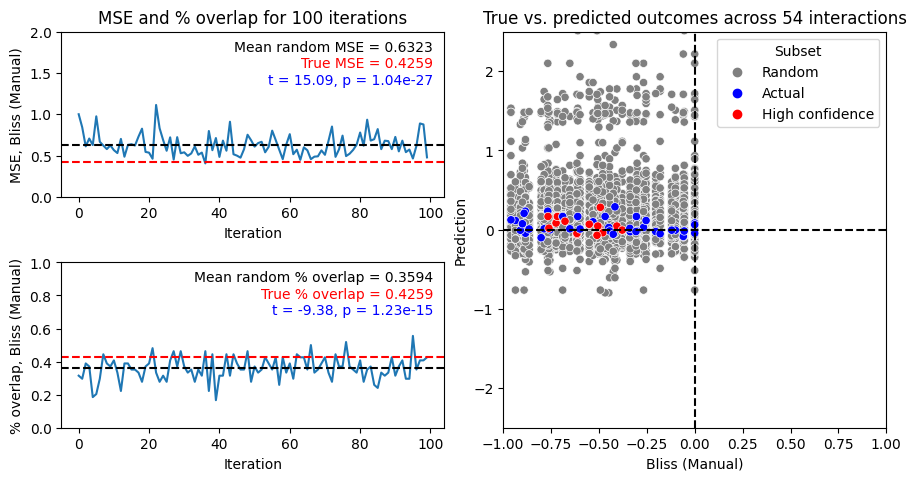

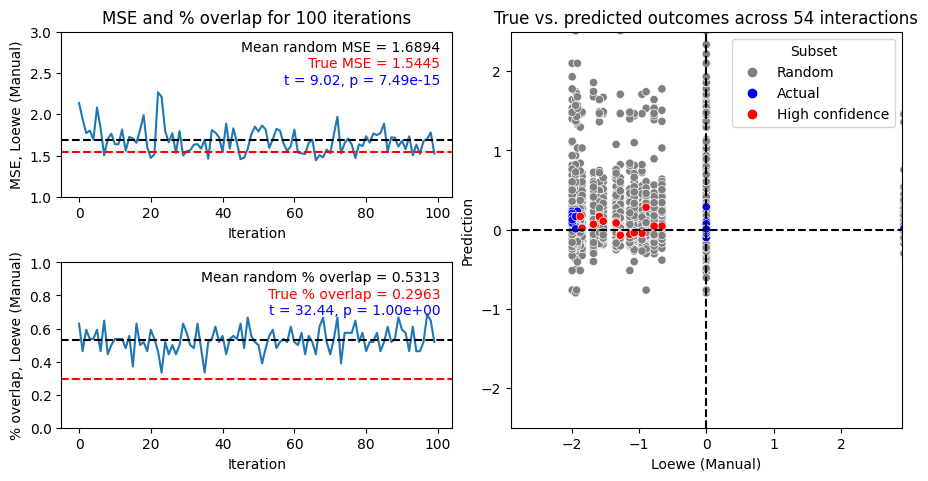

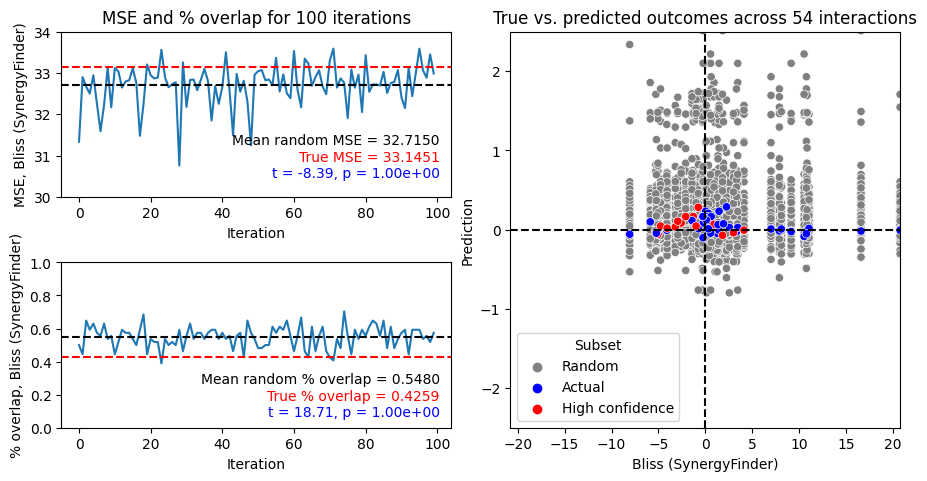

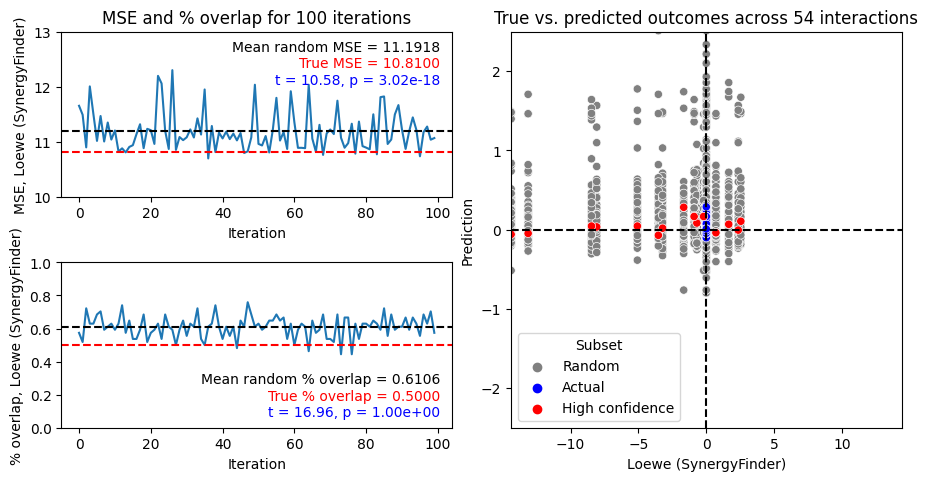

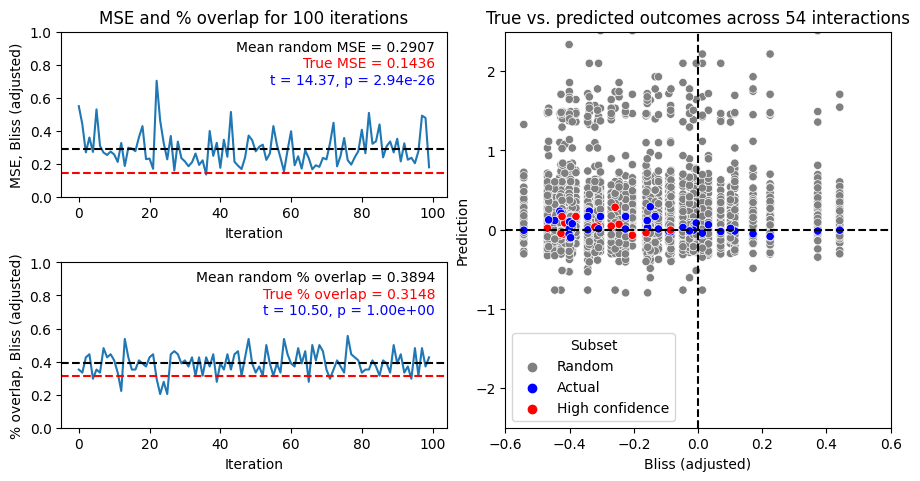

In [11]:
# Visualize plots for all scores
files = {}
for k, method in enumerate(suffix): 
    # Instantiate figure
    fig = plt.figure(figsize=(9, 4.7), layout='constrained')
    gs = fig.add_gridspec(2, 2)
    
    # Define plot data
    # k = 2
    method = suffix[k]
    t1, p1, t2, p2 = dft[method].values
    va1, va2 = 'top', 'top'
    if k==2: 
        va1, va2 = 'bottom', 'bottom'
    if k==3:
        va2 = 'bottom'
    
    # Panel A: MSE lineplot
    ax, metric = fig.add_subplot(gs[0, 0]), 'MSE'
    y = dfr[', '.join([metric, method])]
    sns.lineplot(data=dfr, x='Iteration', y=', '.join([metric, method]), ax=ax)
    ax.set_title('MSE and % overlap for {} iterations'.format(N))
    ax.set(ylim=(floor(y.min()), ceil(y.max())))
    ax.axhline(y.mean(), ls='--', color='k')
    ax.axhline(mse_true[k], ls='--', color='r')
    if va1=='top': 
        y1, y2, y3 = 0.95, 0.85, 0.75
    elif va1=='bottom': 
        y1, y2, y3 = 0.3, 0.2, 0.1
    ax.text(0.97, y1, 'Mean random {} = {:.4f}'.format(metric, y.mean()), color='k', 
        ha='right', va=va1, transform=ax.transAxes)
    ax.text(0.97, y2, 'True {} = {:.4f}'.format(metric, mse_true[k]), color='r', 
        ha='right', va=va1, transform=ax.transAxes)
    ax.text(0.97, y3, 't = {:.2f}, p = {:.2e}'.format(t1, p1), color='b', 
        ha='right', va=va1, transform=ax.transAxes)
    
    # Panel B: % overlap lineplot
    ax, metric = fig.add_subplot(gs[1, 0]), '% overlap'
    y = dfr[', '.join([metric, method])]
    sns.lineplot(data=dfr, x='Iteration', y=', '.join([metric, method]), ax=ax)
    ax.set(ylim=(floor(y.min()), ceil(y.max())))
    ax.axhline(y.mean(), ls='--', color='k')
    ax.axhline(polap_true[k], ls='--', color='r')
    if va2=='top': 
        y1, y2, y3 = 0.95, 0.85, 0.75
    elif va2=='bottom': 
        y1, y2, y3 = 0.25, 0.15, 0.05
    ax.text(0.97, y1, 'Mean random {} = {:.4f}'.format(metric, y.mean()), color='k', 
        ha='right', va=va2, transform=ax.transAxes)
    ax.text(0.97, y2, 'True {} = {:.4f}'.format(metric, polap_true[k]), color='r', 
        ha='right', va=va2, transform=ax.transAxes)
    ax.text(0.97, y3, 't = {:.2f}, p = {:.2e}'.format(t2, p2), color='b', 
        ha='right', va=va2, transform=ax.transAxes)
    
    # Panel C: true vs. prediction scatterplot
    ax = fig.add_subplot(gs[:, 1])
    x = np.tile(y_true[:, k], (1, N + 1)).reshape((-1, ))
    y = np.concatenate([r_pred[:, k, :].reshape((-1, )), y_pred[:, k]])
    df = pd.DataFrame({method: x, 'Prediction': y})
    df['Subset'] = 'Random'
    df['Subset'].iloc[len(y_true)*N:] = ['High confidence' if b=='Double effect' else 'Actual' for b in df_true['Board type']]
    cmap = {'Random': 'gray', 'Actual': 'blue', 'High confidence': 'red'}
    sns.scatterplot(data=df, x=method, y='Prediction', hue='Subset', palette=cmap, ax=ax)
    ax.axhline(0, ls='--', color='k')
    ax.axvline(0, ls='--', color='k')
    xlim, ylim = round(abs(x).max(), 1), round(abs(y).max(), 1)
    ax.set(xlim=(-xlim, xlim), ylim=(-ylim, ylim))
    ax.set_title('True vs. predicted outcomes across {} interactions'.format(len(y_true)))